In [1]:
import re
import matplotlib.pyplot as plt
import numpy as np

LOG_PATH = "results/sgd_gate_run/run.log"

iter_re = re.compile(r"^Iteration (\d+)/")
illegal_re = re.compile(r"Illegal-argmax rate: ([\d.]+)%, mean illegal mass: ([\d.]+)")

iters, argmax_rate, mass = [], [], []
current_iter = None
with open(LOG_PATH) as f:
    for line in f:
        m = iter_re.match(line)
        if m:
            current_iter = int(m.group(1))
            continue
        m = illegal_re.search(line)
        if m and current_iter is not None:
            iters.append(current_iter)
            argmax_rate.append(float(m.group(1)))
            mass.append(float(m.group(2)) * 100)
            current_iter = None

print(f"Parsed {len(iters)} iterations (last: {iters[-1] if iters else 'none'})")

Parsed 192 iterations (last: 191)


NameError: name 'bool_promoted' is not defined

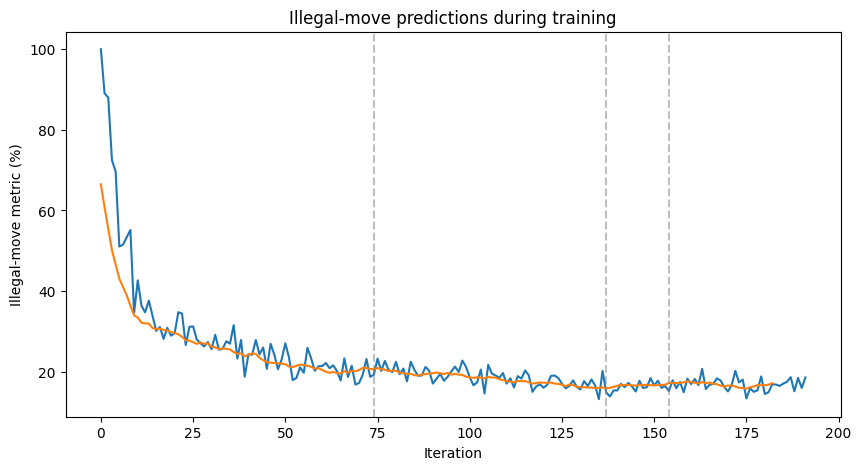

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(argmax_rate, label="Argmax-illegal rate", linewidth=1.5)
argmax_rate_smooth = np.convolve(argmax_rate, np.ones(10) / 10, mode="valid")
ax.plot(argmax_rate_smooth, label="Smoothed Argmax-illegal rate", linewidth=1.5)
# ax.plot(iters, mass, label="Mean illegal probability mass", linewidth=1.5, alpha=0.8)
ax.set_xlabel("Iteration")
ax.set_ylabel("Illegal-move metric (%)")
ax.set_title("Illegal-move predictions during training")
vlines = [74, 137, 154]
for v in vlines:
    ax.axvline(v, color="gray", linestyle="--", alpha=0.5)

ax.scatter(np.where(np.array(bool_promoted) == 1 )[0], np.array(argmax_rate)[np.where(np.array(bool_promoted) == 1 )[0]], color="black", s=10, label="Promoted", zorder=1)

ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
promoted_re = re.compile(r".*Challenger PROMOTED.*")
not_promoted_re = re.compile(r".*Champion retained.*")

bool_promoted = []
with open(LOG_PATH) as f:
    for line in f:
        if promoted_re.match(line):
            print(line.strip())
            bool_promoted.append(1)
        elif not_promoted_re.match(line):
            print(line.strip())
            bool_promoted.append(0)

-> Challenger PROMOTED to best_model
-> Champion retained
-> Challenger PROMOTED to best_model
-> Champion retained
-> Challenger PROMOTED to best_model
-> Champion retained
-> Champion retained
-> Champion retained
-> Challenger PROMOTED to best_model
-> Champion retained
-> Challenger PROMOTED to best_model
-> Champion retained
-> Champion retained
-> Champion retained
-> Challenger PROMOTED to best_model
-> Champion retained
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Champion retained
-> Champion retained
-> Champion retained
-> Champion retained
-> Challenger PROMOTED to best_model
-> Champion retained
-> Champion retained
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Champion retained
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Challenger PROMOTED to best_model
-> Champion re